In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sns.set(rc={'figure.figsize':(10,8)})

# Para suprimir los warnings de scikitlearn por convergencia prematura
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

## Iris DataSet

Cargamos los datos

Mostramos unos pocos datos y la diminsiones del dataset

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                  columns=list(iris['feature_names']) + ['target'])

X = df[iris['feature_names']]
y = df.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Mostramos la distribución de los datos mediante gráficos.

Clase 0: Iris-Setosa

Clase 1: Iris-Versicolour

Clase 2: Iris-Virginica

(150, 5)


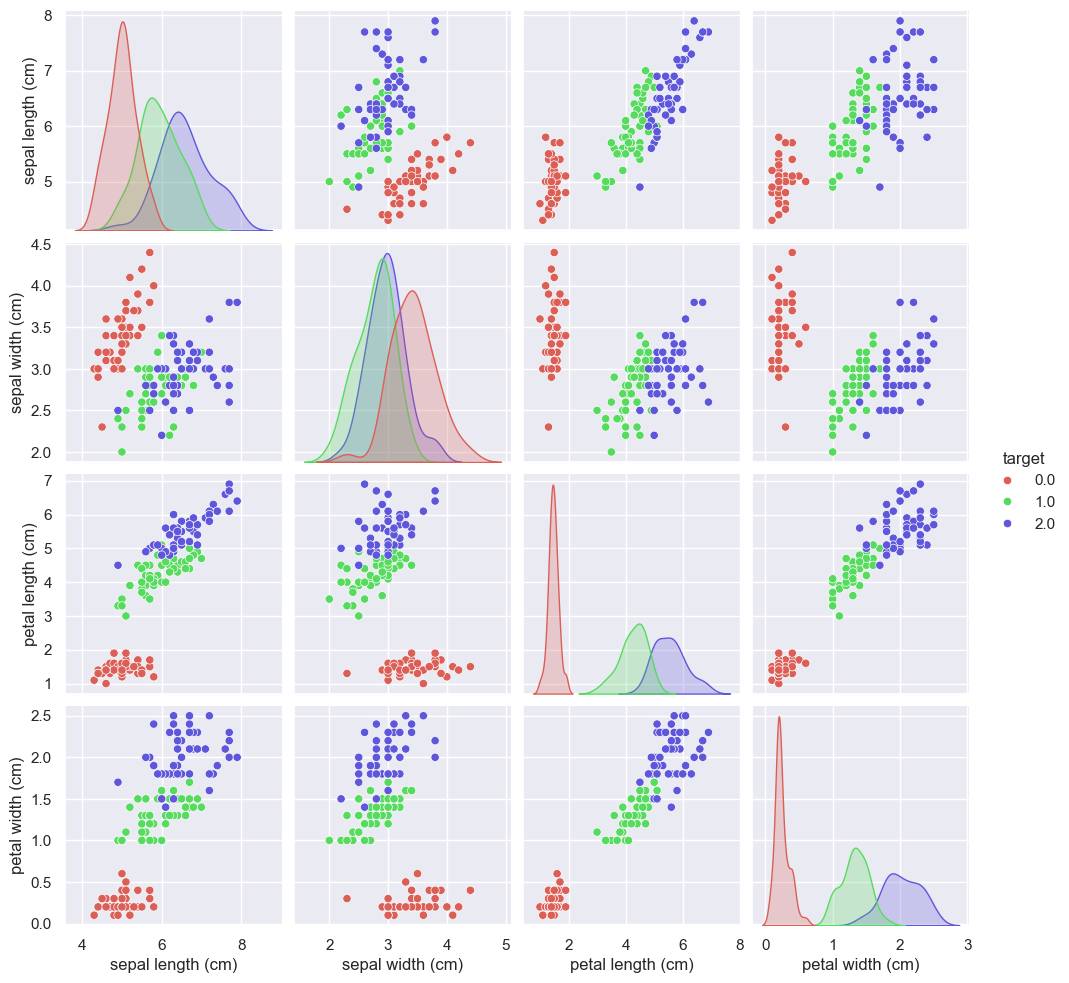

In [6]:
print(df.shape)

sns.pairplot(df, 
             diag_kind="kde", 
             palette=sns.color_palette("hls", 3),
             hue="target")

<Axes: xlabel='tsne-2d-x1', ylabel='tsne-2d-x2'>

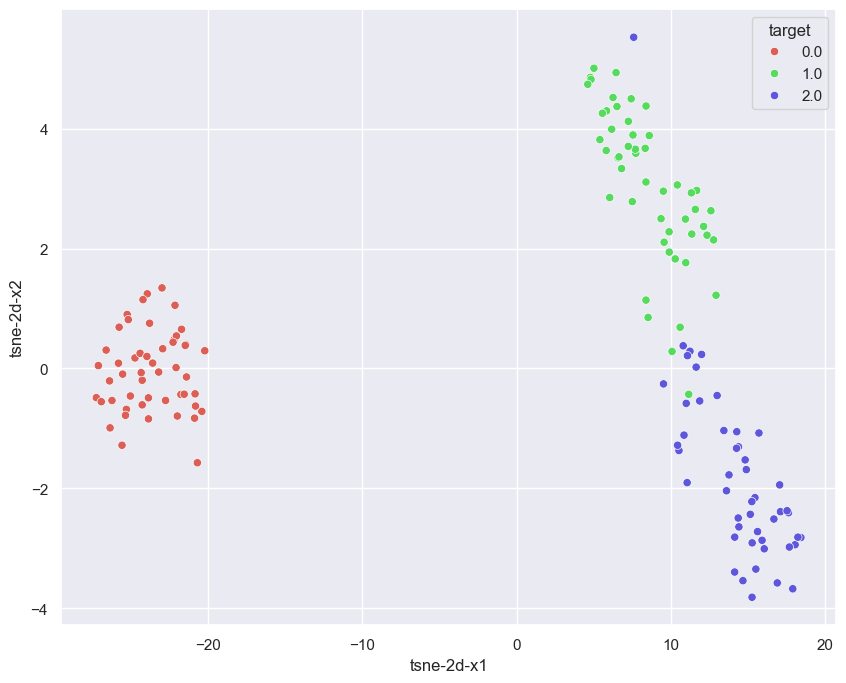

In [7]:
# Usamos tsne para mostrar los datos en 2 dimensiones
from sklearn.manifold import TSNE
# The answer to life, the universe and everything is 42
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

tsne_df = pd.DataFrame(data=X_2d, columns=['tsne-2d-x1', 'tsne-2d-x2'])
tsne_df['target'] = y

# Mostramos los resultados en un gráfico
sns.scatterplot(
    x="tsne-2d-x1", y="tsne-2d-x2",
    data=tsne_df,
    hue="target",
    palette=sns.color_palette("hls", 3),
)

## Preparación de datos
### Obtención de los subconjuntos de entrenamiento y testeo

In [9]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

#TODO (1 linea)
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(112, 4)
(112,)
(38, 4)
(38,)


### Normalización
#### ¿Tiene valores atípicos?
Obtener la media y mediana de cada una de las variables

In [10]:
#Media vs mediana
#TODO
mean = X_train.mean(axis=0)
median = X_train.median(axis=0)

pd.concat([mean, median, mean-median], axis=1, keys=["Media", "Mediana", "Diferencia"])

,Media,Mediana,Diferencia
sepal length (cm),5.830357,5.8,0.030357
sepal width (cm),3.040179,3.0,0.040179
petal length (cm),3.807143,4.3,-0.492857
petal width (cm),1.214286,1.3,-0.085714


Comprobar si tiene valores atípicos. Utilizar la regla de 1.5 el rango intercuartílico.

In [11]:
#TODO
#Obtener 1.5 el rango intercuartilico
iqrx15 = 1.5*(X_train.quantile(.75) - X_train.quantile(.25))
#Obtener los valores maximos
maxs = X_train.max()
#Obtener los valores minimos
mins = X_train.min()
#Definir un limite superior igual a la mediana mas 1.5 veces el rango intercuartilico
sup = median + iqrx15
#Definir un limite inferior igual a la mediana menos 1.5 veces el rango intercuartilico
inf = median - iqrx15
#Comprobar si los valores maximos estan mas alla del limite superior
out_sup = maxs > sup
#Comprobar si los valores minimos estan mas alla del limite inferior
out_inf = mins < inf
#Mostramos para que variables existen valores atipicos
pd.concat([out_sup, out_inf], axis=1, keys=["Outlier Sup", "Outlier Inf"])

,Outlier Sup,Outlier Inf
sepal length (cm),False,False
sepal width (cm),True,True
petal length (cm),False,False
petal width (cm),False,False


Como tiene valores atípicos, utilicemos un método de normalización robusto: RobustScaler

In [12]:
# Normalicemos
from sklearn.preprocessing import RobustScaler
#TODO
# Definir el modelo de normalizacion
scaler = RobustScaler()
# Entrena y normaliza los datos de entrenamiento y testeo
# Utilizar pd.DataFrame(data, columns=df.columns[:-1]) para volver crear un dataframe
X_train_norm = pd.DataFrame(scaler.fit_transform(X_train), columns= df.columns[:-1], index=X_train.index)
X_test_norm = pd.DataFrame(scaler.transform(X_test), columns=df.columns[:-1], index=X_test.index)

#Comprobemos el resultado
pd.concat([ X_train_norm.median(), 
            X_test_norm.median(),
           (X_train_norm.quantile(.75)-X_train_norm.quantile(.25)),
           (X_test_norm.quantile(.75)-X_test_norm.quantile(.25))], 
          axis=1, 
          keys=["Train median", "Test median", "Train iqr", "Test iqr"])

,Train median,Test median,Train iqr,Test iqr
sepal length (cm),0.0,0.076923,1.0,1.038462
sepal width (cm),0.0,0.200000,1.0,1.150000
petal length (cm),0.0,0.042857,1.0,1.014286
petal width (cm),0.0,0.000000,1.0,1.050000


Comparemos los datos los datos normalizados frente a los datos sin normalizar

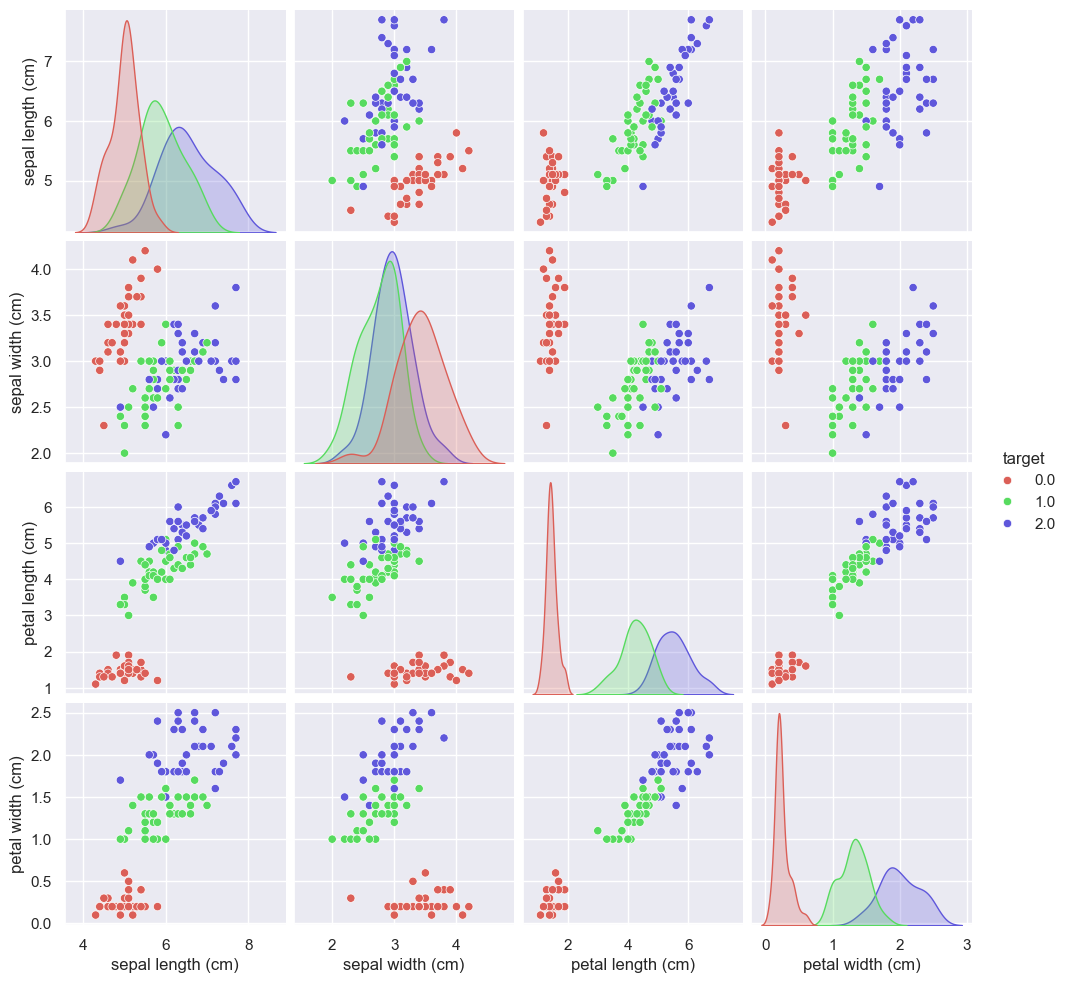

In [ ]:
# Sin normalizar
sns.pairplot(pd.concat([X_train, y_train[:X_train_norm.shape[0]]], axis=1), 
             diag_kind="kde", 
             palette=sns.color_palette("hls", 3),
             hue='target')

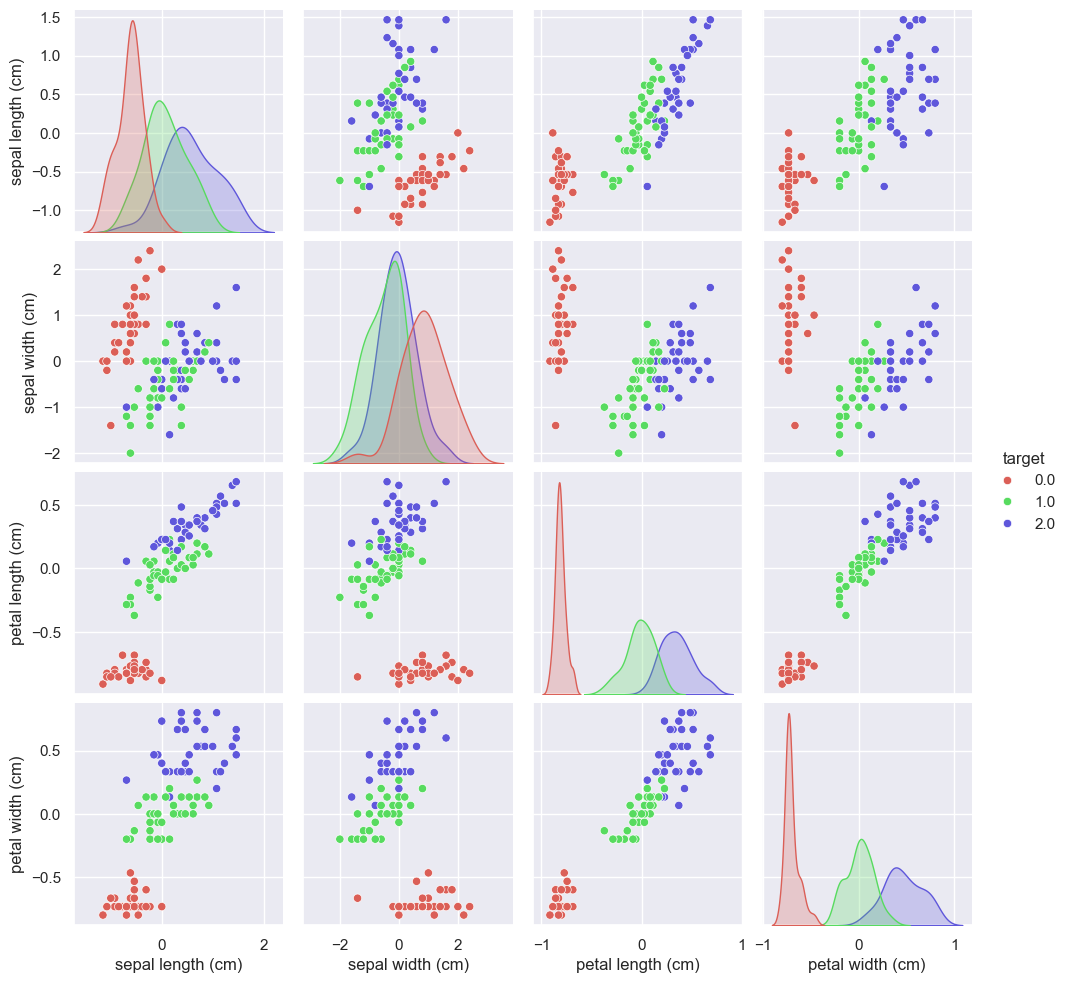

In [13]:
# Normalizado
sns.pairplot(pd.concat([X_train_norm, y_train[:X_train_norm.shape[0]]], axis=1), 
             diag_kind="kde", 
             palette=sns.color_palette("hls", 3),
             hue='target')

## kNN

#### Creación del modelo de clasificación
Utilicemos un modelo de clasificación de tipo kNN
* Crear el modelo
* Entrenarlo
* Comprobar su precisión

In [14]:
#TODO
# Apliquemos Knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error

# Definir el modelo de clasificacion K-nn
neigh = KNeighborsClassifier(10)

# Entrenarlo
neigh.fit(X_train_norm,y_train)

# Obtener las predicciones para el conjunto de datos de testeo
y_est = neigh.predict(X_test_norm)

# Obtener el error cuadratico medio y el precision
MSE_tst = mean_squared_error(y_test,y_est)
accuracy = neigh.score(X_test_norm,y_test)

# Imprimimos el error y precision del modelo
print('MSE : ' + str(MSE_tst))
print('Accuracy: ' + str(accuracy))

MSE : 0.0
Accuracy: 1.0


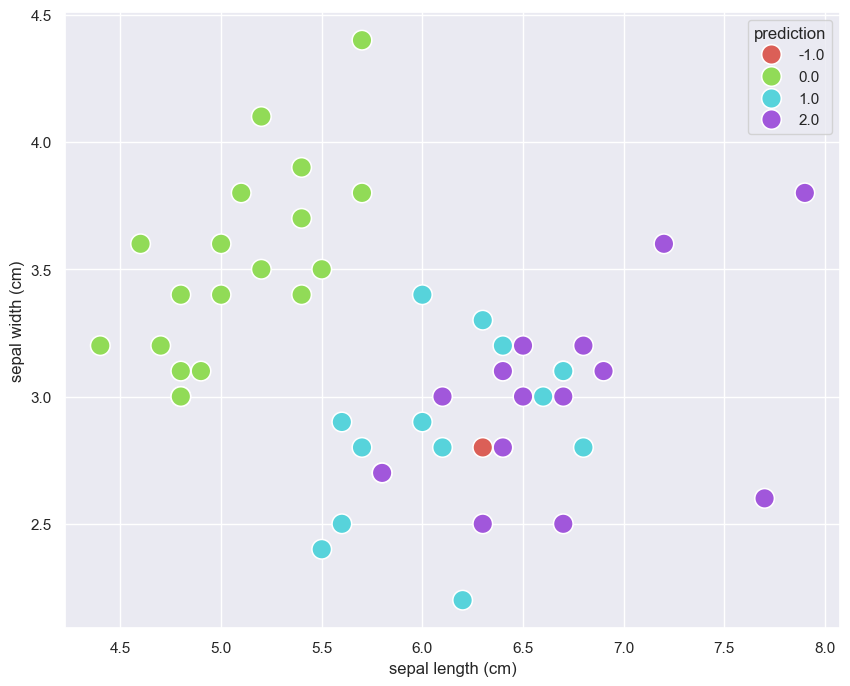

In [ ]:
# Finalmente mostramos los datos para acernos una idea de como de cercana
# es la predicción. Se muestra para el atributosepal length (cm) y sepal width (cm). 
# Cambiar de atributos para comprobar otras dimensiones
results = X_test.copy()
results['target'] = y_test
results['prediction'] = y_est
results['correct'] = results['target'] == results['prediction']
results.loc[~results['correct'],'prediction'] =-1

g = sns.scatterplot(x="sepal length (cm)",
                y="sepal width (cm)",
                hue='prediction',
                data=results,
                palette=sns.color_palette("hls", 4),
                s=200)


# Para problemas binarios
# dtype = pd.CategoricalDtype(['False Positive','True prediction','False Negative'])
# test_data = X_test[["sepal length (cm)", "sepal width (cm)"]].assign(Prediction=pd.Categorical.from_codes(codes=(y_test.values-y_est+1).astype(int), dtype=dtype))
# g = sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue='Prediction', data=test_data, s=200)



#### Matriz de confusión
Mostremos la matriz de confusión para analizar con más detalle donde se encuentran los errores

* Obtener la matriz de confusión con `confusion_matrix`

Confusion matrix
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]
Normalized confusion matrix
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


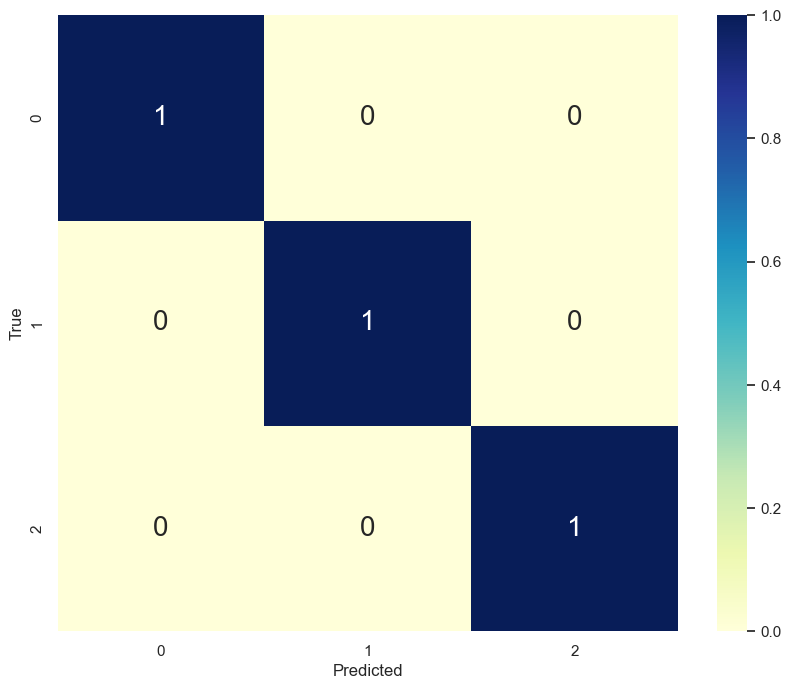

In [15]:
from sklearn.metrics import confusion_matrix

CM = confusion_matrix(y_test,y_est)
print('Confusion matrix')
print(CM)
CM_norm = CM.astype('float') / CM.sum(axis=1)[:, np.newaxis]
print('Normalized confusion matrix')
print(CM_norm)
g = sns.heatmap(CM_norm, annot=True, cmap="YlGnBu", annot_kws={"size": 20}) \
       .set(ylabel='True', xlabel='Predicted')

##### ¿Hemos elegido correctamente el número de vecinos óptimo?
Probemos con distintos números de vecinos

C:\Users\Victor Peiro\AppData\Local\Temp\ipykernel_26596\350676693.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  accs = pd.concat([accs, pd.DataFrame.from_records([{"Neighbors":n_neighbors, "Training Accuracy":acc_tr, "Test Accuracy":acc_test}])], ignore_index=True)


For K = 1, train accuracy is 100.00% and test accuracy is 92.11%
For K = 2, train accuracy is 96.43% and test accuracy is 94.74%
For K = 3, train accuracy is 94.64% and test accuracy is 100.00%
For K = 4, train accuracy is 92.86% and test accuracy is 97.37%
For K = 5, train accuracy is 92.86% and test accuracy is 100.00%
For K = 6, train accuracy is 92.86% and test accuracy is 94.74%
For K = 7, train accuracy is 93.75% and test accuracy is 97.37%
For K = 8, train accuracy is 92.86% and test accuracy is 97.37%
For K = 9, train accuracy is 91.96% and test accuracy is 100.00%
For K = 10, train accuracy is 91.96% and test accuracy is 100.00%
For K = 11, train accuracy is 90.18% and test accuracy is 100.00%
For K = 12, train accuracy is 91.07% and test accuracy is 100.00%
For K = 13, train accuracy is 91.07% and test accuracy is 100.00%
For K = 14, train accuracy is 91.07% and test accuracy is 97.37%
For K = 15, train accuracy is 90.18% and test accuracy is 100.00%
For K = 16, train accurac

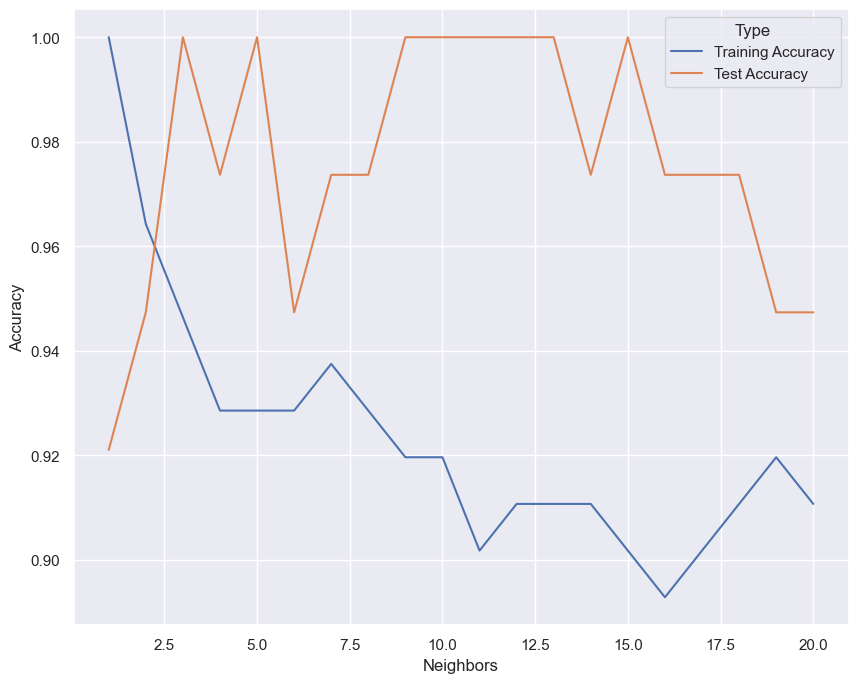

In [18]:
#TODO
K_max=20
rang_K = np.arange(1, K_max+1)
accs = pd.DataFrame(columns=["Neighbors","Training Accuracy", "Test Accuracy"])

# Iteremos sobre diferentes valores para vecinos
for n_neighbors in rang_K:
    # Crear el modelo y entrenarlo
    reg = KNeighborsClassifier(n_neighbors= n_neighbors).fit(X_train_norm, y_train)
    # Obtener la precision para el conjunto de datos de entrenamiento y testeo
    acc_tr = reg.score(X_train_norm,y_train)
    acc_test = reg.score(X_test_norm,y_test)
    
    # Guardamos la precision en un DataFrame para su posterior impresion
    accs = pd.concat([accs, pd.DataFrame.from_records([{"Neighbors":n_neighbors, "Training Accuracy":acc_tr, "Test Accuracy":acc_test}])], ignore_index=True)

    print("For K = %d, train accuracy is %2.2f%% and test accuracy is %2.2f%%"
          % (n_neighbors, 100*acc_tr, 100*acc_test))
    
# Mostremos la evolución de la precision
melted_accs = accs.melt('Neighbors', var_name="Type", value_name="Accuracy")
g = sns.lineplot(x="Neighbors", y="Accuracy", hue='Type', data=melted_accs)

##### ¿Cuál es el número óptimo de vecinos?
Apliquemos mejor validación cruzada con GridSearchCV para obtener el valor óptimo

In [20]:
#TODO
from sklearn.model_selection import GridSearchCV

k_max =20
rang_K = np.arange(1, k_max+1)
tuned_parameters = [{'n_neighbors': rang_K}]
nfold = 5

# Definir el modelo de clasificacion kNN con validación cruzada y entrenarlo
# Configurar CV para que devuelva las puntuaciones de entrenamiento
neigh_CV = GridSearchCV(KNeighborsClassifier(), 
                        tuned_parameters, 
                        cv=nfold, 
                        return_train_score=True).fit(X_train_norm, y_train)

# Obtener las predicciones para el conjunto de datos de testeo
y_est = neigh_CV.predict(X_test_norm)

# Obtener el error cuadratico medio y la precision
MSE_tst = mean_squared_error(y_est,y_test)
accuracy = neigh_CV.score(X_test_norm,y_test)
# Se puede obtener el mejor parametro asi

K_CV = neigh_CV.best_params_['n_neighbors']

print('MSE : ' + str(MSE_tst))
print('Accuracy: ' + str(accuracy))
print('Selected value of k: ' + str(K_CV))

MSE : 0.02631578947368421
Accuracy: 0.9736842105263158
Selected value of k: 7


Mostremos los resultados

Cross validation results:
For K = 1, validation accuracy is 94.00 (+/-1.871)%
For K = 2, validation accuracy is 92.00 (+/-2.550)%
For K = 3, validation accuracy is 93.00 (+/-2.550)%
For K = 4, validation accuracy is 91.00 (+/-2.449)%
For K = 5, validation accuracy is 93.00 (+/-2.000)%
For K = 6, validation accuracy is 94.00 (+/-1.871)%
For K = 7, validation accuracy is 93.00 (+/-2.000)%
For K = 8, validation accuracy is 94.00 (+/-1.871)%
For K = 9, validation accuracy is 93.00 (+/-2.000)%
For K = 10, validation accuracy is 93.00 (+/-2.000)%
For K = 11, validation accuracy is 93.00 (+/-2.000)%
For K = 12, validation accuracy is 92.00 (+/-2.000)%
For K = 13, validation accuracy is 93.00 (+/-2.000)%
For K = 14, validation accuracy is 92.00 (+/-2.550)%
For K = 15, validation accuracy is 92.00 (+/-2.000)%
For K = 16, validation accuracy is 92.00 (+/-2.000)%
For K = 17, validation accuracy is 91.00 (+/-2.449)%
For K = 18, validation accuracy is 92.00 (+/-2.000)%
For K = 19, validation accura

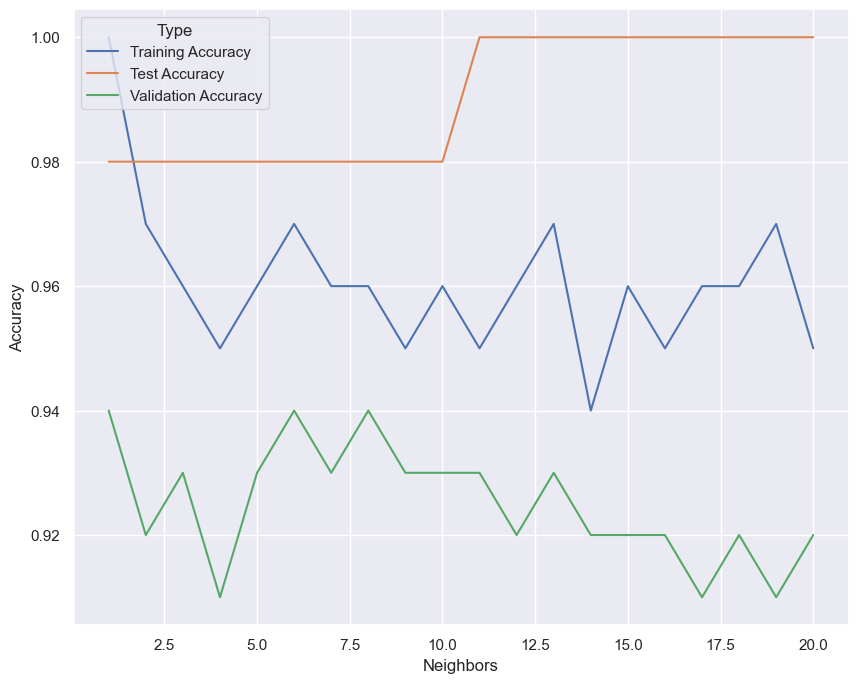

In [ ]:
# Mostremos los resultados
import pandas as pd

print("Cross validation results:")
cv_results = pd.DataFrame(neigh_CV.cv_results_)

for index, row in cv_results.iterrows():
    print("For K = %d, validation accuracy is %2.2f (+/-%1.3f)%%"
        % (row['params']['n_neighbors'], 100 * row['mean_test_score'], 100 * row['std_test_score'] / 2))

# Mostramos los resultados
melted_accs = accs.assign(**{"Validation Accuracy": cv_results.mean_test_score}) \
                  .melt('Neighbors', var_name="Type", value_name="Accuracy")
g = sns.lineplot(x="Neighbors", y="Accuracy", hue='Type', data=melted_accs)